# Coding Exercises (Part 5)

Now, you will have the opportunity to practice what you have learned. <br>
__Follow the instructions__ and insert your code! 

If you need some help or if you want to check your code, you can also have a look at the __solutions__.

### Have Fun!

--------------------------------------------------------------------------------------------------------------

## Exercise 3: Multiple Regression 

Create a __Multiple Regression Model__ explaining a movie´s revenue (dependent variable) for movies released between __Jan-01-2000__ and __Dec-31-2009__. __Process__ the dataset and __select / create__ appropriate features. Which independent variables are __significant__ (required level of significance: 1%)?

In [90]:
#run the cell!
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import ast

In [2]:
#run the cell!
movie = pd.read_csv("movies_metadata.csv", low_memory= False , index_col = "release_date" , parse_dates = True)
movie.head(5)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,production_countries,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
release_date,,,,,,,,,,,,,,,,,,,,,
1995-10-30,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,"[{'iso_3166_1': 'US', 'name': 'United States o...",373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1995-12-15,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
1995-12-22,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
1995-12-22,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,"[{'iso_3166_1': 'US', 'name': 'United States o...",81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
1995-02-10,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [3]:
movie.index =pd.to_datetime(movie.index, errors = "coerce")
movie.sort_index(inplace = True)

In [4]:
if "release_date" in movie.columns:
    print("release_date is in the columns")
else:
    print("release_date is not in the columns")

release_date is not in the columns


In [5]:
movie

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,production_countries,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
release_date,,,,,,,,,,,,,,,,,,,,,
1874-12-09,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,315946,tt3155794,xx,Passage de Venus,Photo sequence of the rare transit of Venus ov...,...,"[{'iso_3166_1': 'FR', 'name': 'France'}]",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Passage of Venus,False,6.0,19.0
1878-06-14,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,194079,tt2221420,en,Sallie Gardner at a Gallop,Sallie Gardner at a Gallop was one of the earl...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Sallie Gardner at a Gallop,False,6.2,25.0
1883-11-19,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,426903,tt5459794,en,Buffalo Running,Individual photographs of the running of a buf...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Buffalo Running,False,5.4,7.0
1887-08-18,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,159897,tt2075247,xx,Man Walking Around a Corner,The last remaining production of Le Prince's L...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Man Walking Around a Corner,False,4.1,17.0
1888-01-01,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,96882,tt1758563,xx,Accordion Player,The last remaining film of Le Prince's LPCCP T...,...,"[{'iso_3166_1': 'GB', 'name': 'United Kingdom'}]",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Accordion Player,False,4.4,18.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaT,False,NaN,0,[],NaN,438910,tt0810384,ru,Konstruktor krasnogo tsveta -1993,Engineering Red - 1993 Dir: Andrey I. Y. Petr...,...,[],0.0,76.0,[],Released,NaN,Engineering Red,False,6.0,2.0
NaT,False,NaN,0,"[{'id': 9648, 'name': 'Mystery'}, {'id': 878, ...",NaN,433711,tt3158690,en,All Superheroes Must Die 2: The Last Superhero,"In a no holds barred documentary, acclaimed jo...",...,[],0.0,74.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,All Superheroes Must Die 2: The Last Superhero,False,4.0,1.0
NaT,False,NaN,0,[],NaN,335251,tt1883368,en,The Land Where the Blues Began,An exploration of the musical and social origi...,...,[],0.0,0.0,[],Released,NaN,The Land Where the Blues Began,False,0.0,0.0


In [6]:
movie = movie[~movie.index.isnull()]
movie

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,production_countries,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
release_date,,,,,,,,,,,,,,,,,,,,,
1874-12-09,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,315946,tt3155794,xx,Passage de Venus,Photo sequence of the rare transit of Venus ov...,...,"[{'iso_3166_1': 'FR', 'name': 'France'}]",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Passage of Venus,False,6.0,19.0
1878-06-14,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,194079,tt2221420,en,Sallie Gardner at a Gallop,Sallie Gardner at a Gallop was one of the earl...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Sallie Gardner at a Gallop,False,6.2,25.0
1883-11-19,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,426903,tt5459794,en,Buffalo Running,Individual photographs of the running of a buf...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Buffalo Running,False,5.4,7.0
1887-08-18,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,159897,tt2075247,xx,Man Walking Around a Corner,The last remaining production of Le Prince's L...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Man Walking Around a Corner,False,4.1,17.0
1888-01-01,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,96882,tt1758563,xx,Accordion Player,The last remaining film of Le Prince's LPCCP T...,...,"[{'iso_3166_1': 'GB', 'name': 'United Kingdom'}]",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Accordion Player,False,4.4,18.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-04-04,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,412059,tt5613402,en,Mobile Homes,"In forgotten towns along the American border, ...",...,"[{'iso_3166_1': 'FR', 'name': 'France'}, {'iso...",0.0,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Post Production,NaN,Mobile Homes,False,0.0,1.0
2018-04-25,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",NaN,332283,tt3906082,en,Mary Shelley,The love affair between poet Percy Shelley and...,...,"[{'iso_3166_1': 'IE', 'name': 'Ireland'}, {'is...",0.0,0.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Post Production,NaN,Mary Shelley,False,0.0,1.0
2018-11-07,False,"{'id': 14890, 'name': 'Bad Boys Collection', '...",0,"[{'id': 53, 'name': 'Thriller'}, {'id': 28, 'n...",NaN,38700,tt1502397,en,Bad Boys for Life,The continuing adventures of Miami detectives ...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,0.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Planned,NaN,Bad Boys for Life,False,0.0,12.0


In [7]:
movie = movie.loc["2000-01-01":"2009-12-31"].copy()
movie.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,production_countries,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
release_date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,False,NaN,555000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,13915,tt0219405,en,Waydowntown,Four young office workers have a bet going to ...,...,"[{'iso_3166_1': 'CA', 'name': 'Canada'}]",0.0,84.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Welcome to life at the bottom of the food chain.,Waydowntown,False,6.0,5.0
2000-01-01,False,"{'id': 382113, 'name': 'Spiders - Collection',...",0,"[{'id': 27, 'name': 'Horror'}, {'id': 878, 'na...",NaN,40039,tt0203940,en,Spiders,A DNA experiment on a rare breed of spider is ...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,94.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Spiders,False,4.3,26.0
2000-01-01,False,NaN,0,"[{'id': 53, 'name': 'Thriller'}]",NaN,58195,tt0169543,it,Almost Blue,"A serial killer, called the Iguana, is terrori...",...,"[{'iso_3166_1': 'IT', 'name': 'Italy'}]",0.0,82.0,"[{'iso_639_1': 'it', 'name': 'Italiano'}]",Released,NaN,Almost Blue,False,6.0,9.0
2000-01-01,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10770, 'n...",NaN,330711,tt0221455,en,One Kill,A Marine captain is on trial for murdering her...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,96.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,One Kill,False,0.0,0.0
2000-01-01,False,NaN,0,"[{'id': 16, 'name': 'Animation'}, {'id': 18, '...",NaN,48617,tt0279079,xx,Father and Daughter,A father says goodbye to his young daughter. I...,...,"[{'iso_3166_1': 'BE', 'name': 'Belgium'}, {'is...",0.0,8.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,Moved to tears in 8 minutes,Father and Daughter,False,7.4,45.0


In [8]:
movie.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'revenue', 'runtime', 'spoken_languages',
       'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count'],
      dtype='object')

In [9]:
movie["original_language"] = movie["original_language"].str.upper()

In [10]:
movie

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,production_countries,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
release_date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,False,NaN,555000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,13915,tt0219405,EN,Waydowntown,Four young office workers have a bet going to ...,...,"[{'iso_3166_1': 'CA', 'name': 'Canada'}]",0.0,84.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Welcome to life at the bottom of the food chain.,Waydowntown,False,6.0,5.0
2000-01-01,False,"{'id': 382113, 'name': 'Spiders - Collection',...",0,"[{'id': 27, 'name': 'Horror'}, {'id': 878, 'na...",NaN,40039,tt0203940,EN,Spiders,A DNA experiment on a rare breed of spider is ...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,94.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Spiders,False,4.3,26.0
2000-01-01,False,NaN,0,"[{'id': 53, 'name': 'Thriller'}]",NaN,58195,tt0169543,IT,Almost Blue,"A serial killer, called the Iguana, is terrori...",...,"[{'iso_3166_1': 'IT', 'name': 'Italy'}]",0.0,82.0,"[{'iso_639_1': 'it', 'name': 'Italiano'}]",Released,NaN,Almost Blue,False,6.0,9.0
2000-01-01,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10770, 'n...",NaN,330711,tt0221455,EN,One Kill,A Marine captain is on trial for murdering her...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,96.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,One Kill,False,0.0,0.0
2000-01-01,False,NaN,0,"[{'id': 16, 'name': 'Animation'}, {'id': 18, '...",NaN,48617,tt0279079,XX,Father and Daughter,A father says goodbye to his young daughter. I...,...,"[{'iso_3166_1': 'BE', 'name': 'Belgium'}, {'is...",0.0,8.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,Moved to tears in 8 minutes,Father and Daughter,False,7.4,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2009-12-30,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",http://www.beingintheworldmovie.com/,170292,tt1515195,EN,Being in the World,Being in the World is a celebration of human b...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A Celebration of being human in a technologica...,Being in the World,False,5.0,1.0
2009-12-31,False,NaN,15000000,"[{'id': 28, 'name': 'Action'}]",http://31-12-2009.ru/,31162,tt1569364,RU,Чёрная Молния,Black Lightning is a Russian superhero film ab...,...,"[{'iso_3166_1': 'RU', 'name': 'Russia'}]",21500000.0,102.0,"[{'iso_639_1': 'ru', 'name': 'Pусский'}]",Released,NaN,Black Lightning,False,5.3,33.0
2009-12-31,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",http://www.racetonowhere.com/,65103,tt1437364,EN,Race to Nowhere,Race to Nowhere is a film containing stories o...,...,[],0.0,85.0,[],Released,The dark side of america's achievement culture.,Race to Nowhere,False,6.0,1.0


In [11]:
movie["production_countries"].iloc[1]

"[{'iso_3166_1': 'US', 'name': 'United States of America'}]"

In [12]:
movie["production_countries"].iloc[1].replace("[", '' ).replace("]", "")

"{'iso_3166_1': 'US', 'name': 'United States of America'}"

We want te remove the `"` located before the `{` in the above line of code.  <br>
So we need to work with the `ast` library:
```python
import ast
ast.literal_eval()
```

In [13]:
ast.literal_eval(movie["production_countries"].iloc[0])


[{'iso_3166_1': 'CA', 'name': 'Canada'}]

In [14]:
# since it is a list with only one element which is a dictionary, we can select the first element using [0] to access the dictionary:
ast.literal_eval(movie["production_countries"].iloc[0])[0]

{'iso_3166_1': 'CA', 'name': 'Canada'}

In [15]:
# Now we can call the keys and values of the dictionary:
ast.literal_eval(movie["production_countries"].iloc[0])[0].keys()

dict_keys(['iso_3166_1', 'name'])

In [16]:
ast.literal_eval(movie["production_countries"].iloc[0])[0].values()

dict_values(['CA', 'Canada'])

In [17]:
movie["production_countries"].isna().sum()

np.int64(0)

In [18]:
movie["production_countries"].apply(
    lambda x: list(ast.literal_eval(x)[0].values()) 
)

IndexError: list index out of range

We can see there are movies with no production country , for example:

In [19]:
movie.loc["2009-12-31" , ["genres", "production_countries"]]

,genres,production_countries
release_date,,
2009-12-31,"[{'id': 28, 'name': 'Action'}]","[{'iso_3166_1': 'RU', 'name': 'Russia'}]"
2009-12-31,"[{'id': 99, 'name': 'Documentary'}]",[]
2009-12-31,"[{'id': 18, 'name': 'Drama'}, {'id': 28, 'name...","[{'iso_3166_1': 'US', 'name': 'United States o..."
2009-12-31,"[{'id': 10769, 'name': 'Foreign'}, {'id': 53, ...","[{'iso_3166_1': 'IN', 'name': 'India'}]"


in order to avoid the the empty list in the production country we will add the following line of code:
```python
    if pd.notna(x) and len(ast.literal_eval(x)) > 0 
    else None
```

In [20]:
movie["production_countries"].apply(
    lambda x: list(ast.literal_eval(x)[0].values())
    if pd.notna(x) and len(ast.literal_eval(x)) > 0 
    else None
)

release_date
2000-01-01                      [CA, Canada]
2000-01-01    [US, United States of America]
2000-01-01                       [IT, Italy]
2000-01-01    [US, United States of America]
2000-01-01                     [BE, Belgium]
                           ...              
2009-12-30    [US, United States of America]
2009-12-31                      [RU, Russia]
2009-12-31                              None
2009-12-31    [US, United States of America]
2009-12-31                       [IN, India]
Name: production_countries, Length: 11207, dtype: object

Now to retreive the country code:
```python
lambda x: list(ast.literal_eval(x)[0].values())[0]
```

and for the whole name of the country:
```python
lambda x: list(ast.literal_eval(x)[0].values())[1]
```

In [21]:
movie["production_country_code"] = movie["production_countries"].apply(
    lambda x: list(ast.literal_eval(x)[0].values())[0] 
    if pd.notna(x) and len(ast.literal_eval(x)) > 0 
    else None
)

In [22]:
movie["production_country_name"] = movie["production_countries"].apply(
    lambda x: list(ast.literal_eval(x)[0].values())[1] 
    if pd.notna(x) and len(ast.literal_eval(x)) > 0 
    else None
)

In [23]:
movie.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,production_country_code,production_country_name
release_date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,False,NaN,555000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,13915,tt0219405,EN,Waydowntown,Four young office workers have a bet going to ...,...,84.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Welcome to life at the bottom of the food chain.,Waydowntown,False,6.0,5.0,CA,Canada
2000-01-01,False,"{'id': 382113, 'name': 'Spiders - Collection',...",0,"[{'id': 27, 'name': 'Horror'}, {'id': 878, 'na...",NaN,40039,tt0203940,EN,Spiders,A DNA experiment on a rare breed of spider is ...,...,94.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Spiders,False,4.3,26.0,US,United States of America
2000-01-01,False,NaN,0,"[{'id': 53, 'name': 'Thriller'}]",NaN,58195,tt0169543,IT,Almost Blue,"A serial killer, called the Iguana, is terrori...",...,82.0,"[{'iso_639_1': 'it', 'name': 'Italiano'}]",Released,NaN,Almost Blue,False,6.0,9.0,IT,Italy
2000-01-01,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10770, 'n...",NaN,330711,tt0221455,EN,One Kill,A Marine captain is on trial for murdering her...,...,96.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,One Kill,False,0.0,0.0,US,United States of America
2000-01-01,False,NaN,0,"[{'id': 16, 'name': 'Animation'}, {'id': 18, '...",NaN,48617,tt0279079,XX,Father and Daughter,A father says goodbye to his young daughter. I...,...,8.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,Moved to tears in 8 minutes,Father and Daughter,False,7.4,45.0,BE,Belgium


In [33]:
movie["genres"].iloc[100]

"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, 'name': 'Romance'}, {'id': 878, 'name': 'Science Fiction'}]"

In [35]:
movie["spoken_languages"].iloc[10]

'[]'

In [37]:
movie["spoken_languages"].iloc[5]

"[{'iso_639_1': 'en', 'name': 'English'}]"

In [41]:
movie["spoken_languages"].iloc[5]

"[{'iso_639_1': 'en', 'name': 'English'}]"

In [49]:
list(ast.literal_eval(movie["spoken_languages"].iloc[5])[0].values())[1]

'English'

In [51]:
movie["spoken_languages"].apply(
    lambda x: list(ast.literal_eval(x)[0].values())[1] 
    if pd.notna(x) and len(ast.literal_eval(x)) > 0 
    else None
)

release_date
2000-01-01        English
2000-01-01        English
2000-01-01       Italiano
2000-01-01        English
2000-01-01    No Language
                 ...     
2009-12-30        English
2009-12-31        Pусский
2009-12-31           None
2009-12-31        English
2009-12-31         हिन्दी
Name: spoken_languages, Length: 11207, dtype: object

In [52]:
movie["parsed_spoken_languages"] = movie["spoken_languages"].apply(
    lambda x: list(ast.literal_eval(x)[0].values())[1] 
    if pd.notna(x) and len(ast.literal_eval(x)) > 0 
    else None
)

In [26]:
movie["video"].value_counts()

video
False    11161
True        46
Name: count, dtype: int64

In [29]:
movie["status"].value_counts()

status
Released         11095
Rumored             73
Canceled             1
In Production        1
Name: count, dtype: int64

In [56]:
movie.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'revenue', 'runtime', 'spoken_languages',
       'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count',
       'production_country_code', 'production_country_name',
       'parsed_spoken_languages'],
      dtype='object')

In [57]:
movie.loc[movie["production_country_code"].isna(), ["production_country_name", "parsed_spoken_languages", "original_language"]]

,production_country_name,parsed_spoken_languages,original_language
release_date,,,
2000-01-01,None,हिन्दी,HI
2000-01-01,None,None,EN
2000-01-01,None,None,EN
2000-01-01,None,Íslenska,EN
2000-01-01,None,None,EN
...,...,...,...
2009-12-17,None,한국어/조선말,KO
2009-12-18,None,Türkçe,TR
2009-12-25,None,Deutsch,DE


In [54]:
movie["parsed_spoken_languages"].value_counts()

parsed_spoken_languages
English        6176
Français        615
日本語             389
Deutsch         373
Español         339
               ... 
Kinyarwanda       1
Slovenčina        1
پښتو              1
Bokmål            1
Cymraeg           1
Name: count, Length: 65, dtype: int64

In [58]:
movie["production_country_name"].value_counts()

production_country_name
United States of America    3667
France                       670
United Kingdom               616
Canada                       540
Germany                      526
                            ... 
Senegal                        1
Jamaica                        1
Georgia                        1
Mauritania                     1
Albania                        1
Name: count, Length: 104, dtype: int64

Now we can define the Countries name and ticker:
```python

```

In [59]:
movie

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,spoken_languages,status,tagline,title,video,vote_average,vote_count,production_country_code,production_country_name,parsed_spoken_languages
release_date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,False,NaN,555000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,13915,tt0219405,EN,Waydowntown,Four young office workers have a bet going to ...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Welcome to life at the bottom of the food chain.,Waydowntown,False,6.0,5.0,CA,Canada,English
2000-01-01,False,"{'id': 382113, 'name': 'Spiders - Collection',...",0,"[{'id': 27, 'name': 'Horror'}, {'id': 878, 'na...",NaN,40039,tt0203940,EN,Spiders,A DNA experiment on a rare breed of spider is ...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Spiders,False,4.3,26.0,US,United States of America,English
2000-01-01,False,NaN,0,"[{'id': 53, 'name': 'Thriller'}]",NaN,58195,tt0169543,IT,Almost Blue,"A serial killer, called the Iguana, is terrori...",...,"[{'iso_639_1': 'it', 'name': 'Italiano'}]",Released,NaN,Almost Blue,False,6.0,9.0,IT,Italy,Italiano
2000-01-01,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10770, 'n...",NaN,330711,tt0221455,EN,One Kill,A Marine captain is on trial for murdering her...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,One Kill,False,0.0,0.0,US,United States of America,English
2000-01-01,False,NaN,0,"[{'id': 16, 'name': 'Animation'}, {'id': 18, '...",NaN,48617,tt0279079,XX,Father and Daughter,A father says goodbye to his young daughter. I...,...,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,Moved to tears in 8 minutes,Father and Daughter,False,7.4,45.0,BE,Belgium,No Language
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2009-12-30,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",http://www.beingintheworldmovie.com/,170292,tt1515195,EN,Being in the World,Being in the World is a celebration of human b...,...,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,A Celebration of being human in a technologica...,Being in the World,False,5.0,1.0,US,United States of America,English
2009-12-31,False,NaN,15000000,"[{'id': 28, 'name': 'Action'}]",http://31-12-2009.ru/,31162,tt1569364,RU,Чёрная Молния,Black Lightning is a Russian superhero film ab...,...,"[{'iso_639_1': 'ru', 'name': 'Pусский'}]",Released,NaN,Black Lightning,False,5.3,33.0,RU,Russia,Pусский
2009-12-31,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",http://www.racetonowhere.com/,65103,tt1437364,EN,Race to Nowhere,Race to Nowhere is a film containing stories o...,...,[],Released,The dark side of america's achievement culture.,Race to Nowhere,False,6.0,1.0,None,None,None


In [61]:
movie["genres"].iloc[100]

"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, 'name': 'Romance'}, {'id': 878, 'name': 'Science Fiction'}]"

In [65]:
ast.literal_eval(movie["genres"].iloc[100])

[{'id': 35, 'name': 'Comedy'},
 {'id': 10749, 'name': 'Romance'},
 {'id': 878, 'name': 'Science Fiction'}]

In [74]:
movie.iloc[100 , :].to_frame()

,2000-01-25
adult,False
belongs_to_collection,NaN
budget,0
genres,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '..."
homepage,NaN
id,22230
imdb_id,tt0208196
original_language,EN
original_title,Happy Accidents
overview,A comedy that pays tribute to the science fict...


movie.columns

In [ ]:
df = movie[["title", "budget", "revenue", "vote_average", "popularity", "runtime",
            "belongs_to_collection", "original_language"]].copy()

In [77]:
df

,title,budget,revenue,vote_average,popularity,runtime,belongs_to_collection,original_language
release_date,,,,,,,,
2000-01-01,Waydowntown,555000,0.0,6.0,0.506962,84.0,NaN,EN
2000-01-01,Spiders,0,0.0,4.3,1.831412,94.0,"{'id': 382113, 'name': 'Spiders - Collection',...",EN
2000-01-01,Almost Blue,0,0.0,6.0,0.588541,82.0,NaN,IT
2000-01-01,One Kill,0,0.0,0.0,0.008218,96.0,NaN,EN
2000-01-01,Father and Daughter,0,0.0,7.4,1.000408,8.0,NaN,XX
...,...,...,...,...,...,...,...,...
2009-12-30,Being in the World,0,0.0,5.0,0.059265,81.0,NaN,EN
2009-12-31,Black Lightning,15000000,21500000.0,5.3,3.931527,102.0,NaN,RU
2009-12-31,Race to Nowhere,0,0.0,6.0,0.246243,85.0,NaN,EN


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11207 entries, 2000-01-01 to 2009-12-31
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  11207 non-null  object 
 1   budget                 11207 non-null  object 
 2   revenue                11207 non-null  float64
 3   vote_average           11207 non-null  float64
 4   popularity             11207 non-null  object 
 5   runtime                11156 non-null  float64
 6   belongs_to_collection  1204 non-null   object 
 7   original_language      11204 non-null  object 
dtypes: float64(3), object(5)
memory usage: 1.0+ MB


In [80]:
df["budget"] = pd.to_numeric(df["budget"], errors = "coerce")

In [82]:
df["popularity"] = pd.to_numeric(df["popularity"], errors = "coerce")

In [85]:
df.loc[(df["budget"] > 0) & (df["revenue"] > 0)]

,title,budget,revenue,vote_average,popularity,runtime,belongs_to_collection,original_language
release_date,,,,,,,,
2000-01-12,Next Friday,11000000,59827328.0,6.5,10.065450,98.0,"{'id': 43563, 'name': 'Friday Collection', 'po...",EN
2000-01-14,Supernova,90000000,14828081.0,4.9,5.496624,91.0,NaN,EN
2000-01-24,Saving Grace,10000000,26330482.0,6.3,5.139550,93.0,NaN,EN
2000-01-28,Isn't She Great,36000000,3003296.0,4.6,0.907927,95.0,NaN,DE
2000-02-01,The Broken Hearts Club: A Romantic Comedy,1000000,1744858.0,6.3,1.795849,94.0,NaN,EN
...,...,...,...,...,...,...,...,...
2009-12-23,Sherlock Holmes,90000000,524028679.0,7.0,15.686040,128.0,"{'id': 102322, 'name': 'Sherlock Holmes Collec...",EN
2009-12-23,It's Complicated,85000000,219103655.0,6.2,9.083133,121.0,NaN,EN
2009-12-23,3 Idiots,9000000,70000000.0,7.8,7.675621,170.0,NaN,HI


In [86]:
df= df.loc[(df["budget"] > 0) & (df["revenue"] > 0)]
df

,title,budget,revenue,vote_average,popularity,runtime,belongs_to_collection,original_language
release_date,,,,,,,,
2000-01-12,Next Friday,11000000,59827328.0,6.5,10.065450,98.0,"{'id': 43563, 'name': 'Friday Collection', 'po...",EN
2000-01-14,Supernova,90000000,14828081.0,4.9,5.496624,91.0,NaN,EN
2000-01-24,Saving Grace,10000000,26330482.0,6.3,5.139550,93.0,NaN,EN
2000-01-28,Isn't She Great,36000000,3003296.0,4.6,0.907927,95.0,NaN,DE
2000-02-01,The Broken Hearts Club: A Romantic Comedy,1000000,1744858.0,6.3,1.795849,94.0,NaN,EN
...,...,...,...,...,...,...,...,...
2009-12-23,Sherlock Holmes,90000000,524028679.0,7.0,15.686040,128.0,"{'id': 102322, 'name': 'Sherlock Holmes Collec...",EN
2009-12-23,It's Complicated,85000000,219103655.0,6.2,9.083133,121.0,NaN,EN
2009-12-23,3 Idiots,9000000,70000000.0,7.8,7.675621,170.0,NaN,HI


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1780 entries, 2000-01-12 to 2009-12-31
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  1780 non-null   object 
 1   budget                 1780 non-null   int64  
 2   revenue                1780 non-null   float64
 3   vote_average           1780 non-null   float64
 4   popularity             1780 non-null   float64
 5   runtime                1779 non-null   float64
 6   belongs_to_collection  409 non-null    object 
 7   original_language      1780 non-null   object 
dtypes: float64(4), int64(1), object(3)
memory usage: 125.2+ KB


In [107]:
df["belongs_to_collection"] = df["belongs_to_collection"].notnull()

C:\Users\ahmad\AppData\Local\Temp\ipykernel_9584\1453153447.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["belongs_to_collection"] = df["belongs_to_collection"].notnull()


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1780 entries, 2000-01-12 to 2009-12-31
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  1780 non-null   object 
 1   budget                 1780 non-null   int64  
 2   revenue                1780 non-null   float64
 3   vote_average           1780 non-null   float64
 4   popularity             1780 non-null   float64
 5   runtime                1779 non-null   float64
 6   belongs_to_collection  1780 non-null   bool   
 7   original_language      1780 non-null   object 
dtypes: bool(1), float64(4), int64(1), object(2)
memory usage: 113.0+ KB


In [115]:
df.dropna(subset = ["runtime"], inplace = True)

C:\Users\ahmad\AppData\Local\Temp\ipykernel_9584\3986893255.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset = ["runtime"], inplace = True)


In [116]:
df.set_index("title", inplace = True)

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1779 entries, Next Friday to Black Lightning
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   budget                 1779 non-null   int64  
 1   revenue                1779 non-null   float64
 2   vote_average           1779 non-null   float64
 3   popularity             1779 non-null   float64
 4   runtime                1779 non-null   float64
 5   belongs_to_collection  1779 non-null   bool   
 6   original_language      1779 non-null   object 
dtypes: bool(1), float64(4), int64(1), object(1)
memory usage: 99.0+ KB


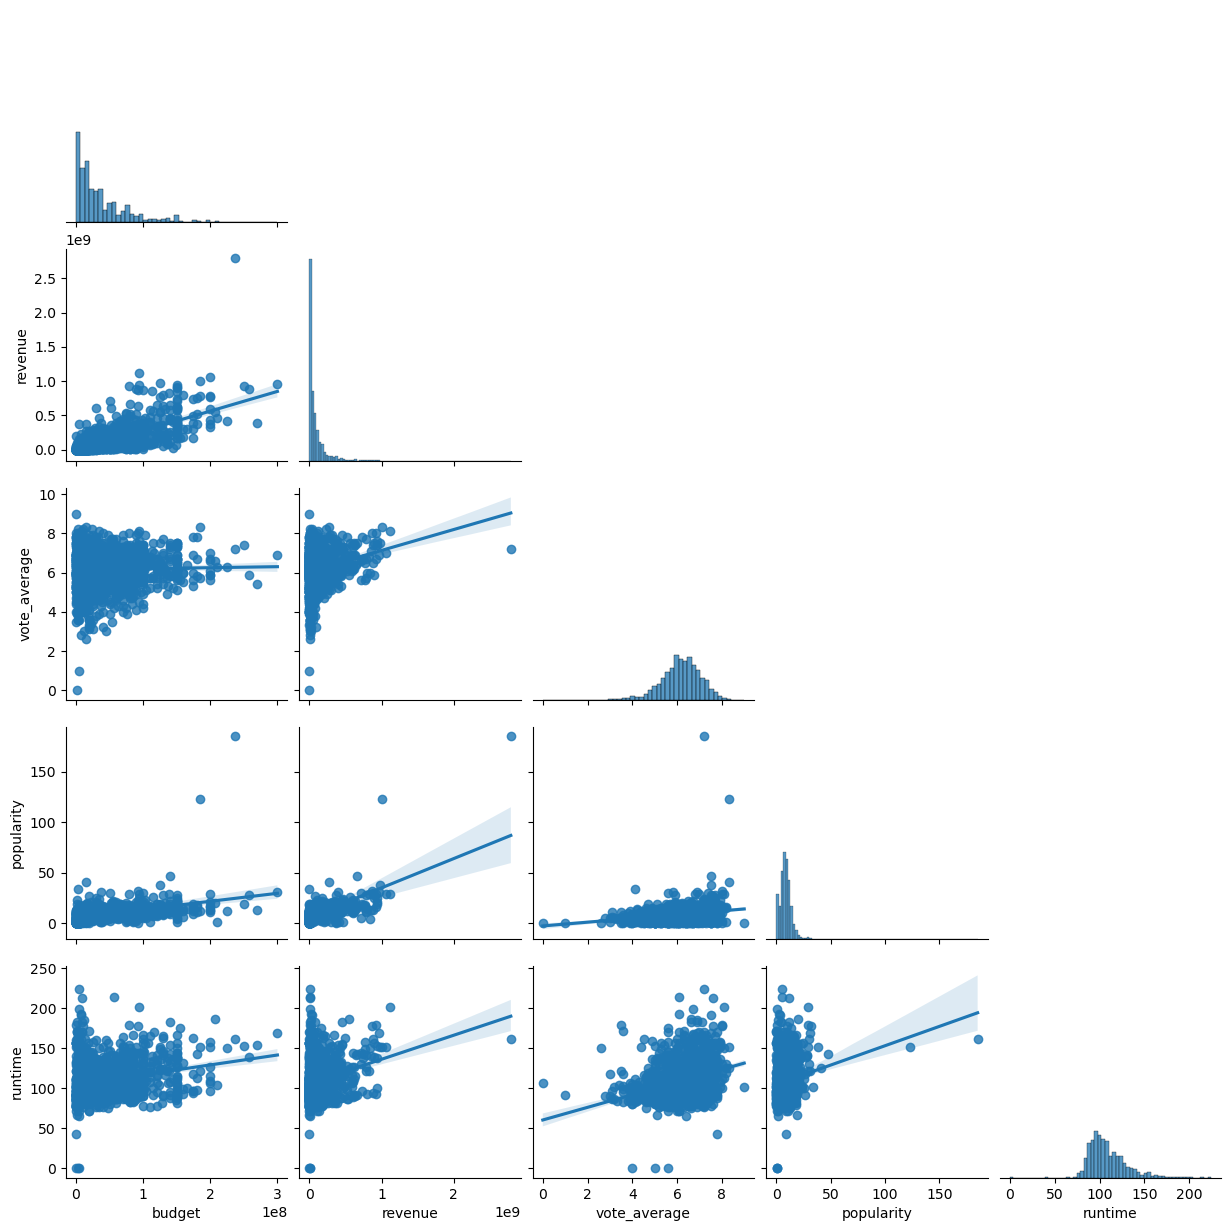

In [119]:
sns.pairplot(df.select_dtypes("number"), corner = True , kind = "reg")
plt.show()

In [120]:
help(df.corr)

Help on method corr in module pandas.core.frame:

corr(
    method: 'CorrelationMethod' = 'pearson',
    min_periods: 'int' = 1,
    numeric_only: 'bool' = False
) -> 'DataFrame' method of pandas.core.frame.DataFrame instance
    Compute pairwise correlation of columns, excluding NA/null values.

    Parameters
    ----------
    method : {'pearson', 'kendall', 'spearman'} or callable
        Method of correlation:

        * pearson : standard correlation coefficient
        * kendall : Kendall Tau correlation coefficient
        * spearman : Spearman rank correlation
        * callable: callable with input two 1d ndarrays
            and returning a float. Note that the returned matrix from corr
            will have 1 along the diagonals and will be symmetric
            regardless of the callable's behavior.
    min_periods : int, optional
        Minimum number of observations required per pair of columns
        to have a valid result. Currently only available for Pearson
       

In [127]:
df.corr(numeric_only = True).sort_values(by = "revenue", ascending = False).style.background_gradient(cmap='coolwarm')

,budget,revenue,vote_average,popularity,runtime,belongs_to_collection
revenue,0.711004,1.000000,0.194813,0.660515,0.235133,0.353621
budget,1.000000,0.711004,0.023039,0.446561,0.239468,0.214218
popularity,0.446561,0.660515,0.232864,1.000000,0.166198,0.209654
belongs_to_collection,0.214218,0.353621,-0.040811,0.209654,-0.056308,1.000000
runtime,0.239468,0.235133,0.337976,0.166198,1.000000,-0.056308
vote_average,0.023039,0.194813,1.000000,0.232864,0.337976,-0.040811


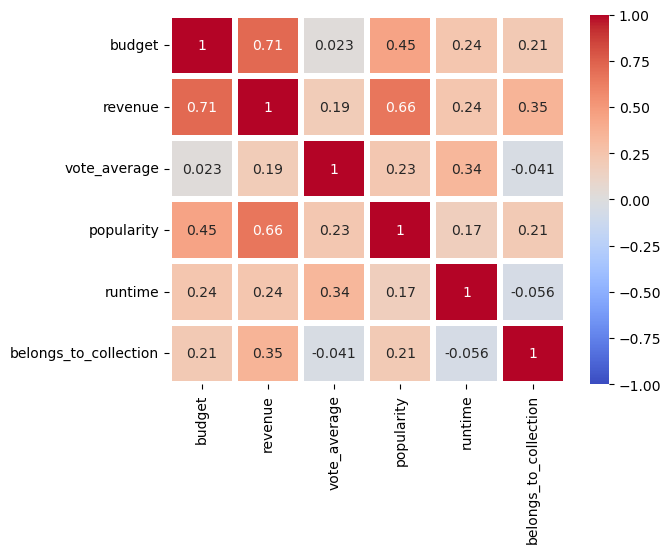

In [126]:
sns.heatmap(df.corr(numeric_only = True), annot = True, cmap = "coolwarm", linewidths = 3 , vmin = -1 , vmax = +1)
plt.show()

In [132]:
model = ols("revenue ~ budget + popularity  + belongs_to_collection  + vote_average", data = df)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.687
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     973.9
Date:                Tue, 23 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:14:44   Log-Likelihood:                -35122.
No. Observations:                1779   AIC:                         7.025e+04
Df Residuals:                    1774   BIC:                         7.028e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [138]:
df_dumm = pd.get_dummies(df, columns = ["belongs_to_collection", "original_language"] , dtype = "int" , drop_first = True)
df_dumm

,budget,revenue,vote_average,popularity,runtime,belongs_to_collection_True,original_language_BM,original_language_CN,original_language_DA,original_language_DE,...,original_language_RO,original_language_RU,original_language_SR,original_language_SV,original_language_TA,original_language_TE,original_language_TH,original_language_TR,original_language_VI,original_language_ZH
title,,,,,,,,,,,,,,,,,,,,,
Next Friday,11000000,59827328.0,6.5,10.065450,98.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Supernova,90000000,14828081.0,4.9,5.496624,91.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Saving Grace,10000000,26330482.0,6.3,5.139550,93.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Isn't She Great,36000000,3003296.0,4.6,0.907927,95.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
The Broken Hearts Club: A Romantic Comedy,1000000,1744858.0,6.3,1.795849,94.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sherlock Holmes,90000000,524028679.0,7.0,15.686040,128.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
It's Complicated,85000000,219103655.0,6.2,9.083133,121.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3 Idiots,9000000,70000000.0,7.8,7.675621,170.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


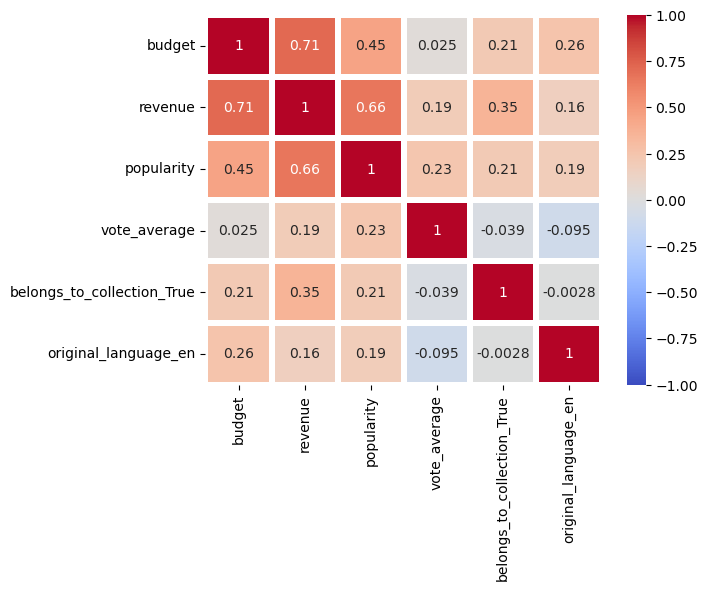

In [164]:
sns.heatmap(df_dumm[["budget", "revenue", "popularity", "vote_average" , "belongs_to_collection_True" , "original_language_en"]].corr(numeric_only = True), annot = True, cmap = "coolwarm", linewidths = 3 , vmin = -1 , vmax = +1)
plt.show()

In [168]:
df["original_language"].value_counts()

original_language
en    1561
hi      37
ru      35
fr      29
es      17
ja      16
it      10
zh      10
ko       9
de       9
ta       8
cn       5
nl       4
sv       4
da       4
te       3
pt       3
pl       2
th       2
fi       2
ro       2
tr       2
sr       1
af       1
vi       1
bm       1
he       1
no       1
Name: count, dtype: int64

In [175]:
df["original_language"].value_counts()[:9]

original_language
en    1561
hi      37
ru      35
fr      29
es      17
ja      16
it      10
zh      10
ko       9
Name: count, dtype: int64

In [176]:
df["original_language"].value_counts()[:9].index

Index(['en', 'hi', 'ru', 'fr', 'es', 'ja', 'it', 'zh', 'ko'], dtype='object', name='original_language')

In [189]:
top9_lang = df["original_language"].value_counts()[:9].index.tolist()
top9_lang

['en', 'hi', 'ru', 'fr', 'es', 'ja', 'it', 'zh', 'ko']

In [197]:
df["original_language"].isin(top9_lang)

title
Next Friday                                   True
Supernova                                     True
Saving Grace                                  True
Isn't She Great                              False
The Broken Hearts Club: A Romantic Comedy     True
                                             ...  
Sherlock Holmes                               True
It's Complicated                              True
3 Idiots                                      True
The Lovely Bones                              True
Black Lightning                               True
Name: original_language, Length: 1780, dtype: bool

In [200]:
df.loc[df["original_language"].isin(top9_lang)].sort_values(by = "original_language", ascending = True)

,budget,revenue,vote_average,popularity,runtime,belongs_to_collection,original_language
title,,,,,,,
Next Friday,11.0,59.827328,6.5,10.065450,98.0,True,en
The Good Shepherd,85.0,59.908565,6.3,11.057536,167.0,False,en
300,65.0,422.610419,7.0,18.108408,117.0,True,en
Smokin' Aces,17.0,57.103895,6.4,7.906434,109.0,True,en
The Holiday,85.0,194.168700,6.7,14.043416,136.0,False,en
...,...,...,...,...,...,...,...
Mulan: Rise of a Warrior,12.0,13.380561,6.9,2.977779,115.0,False,zh
2046,12.0,19.271312,6.9,7.157169,129.0,True,zh
The Children of Huang Shi,40.0,7.400000,6.5,14.622493,125.0,False,zh


In [201]:
df_dumm_new = pd.get_dummies(df, columns = ["belongs_to_collection", "original_language"] , dtype = "int" , drop_first = True)
df_dumm_new

,budget,revenue,vote_average,popularity,runtime,belongs_to_collection_True,original_language_bm,original_language_cn,original_language_da,original_language_de,...,original_language_ro,original_language_ru,original_language_sr,original_language_sv,original_language_ta,original_language_te,original_language_th,original_language_tr,original_language_vi,original_language_zh
title,,,,,,,,,,,,,,,,,,,,,
Next Friday,11.0,59.827328,6.5,10.065450,98.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Supernova,90.0,14.828081,4.9,5.496624,91.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Saving Grace,10.0,26.330482,6.3,5.139550,93.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Isn't She Great,36.0,3.003296,4.6,0.907927,95.0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
The Broken Hearts Club: A Romantic Comedy,1.0,1.744858,6.3,1.795849,94.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sherlock Holmes,90.0,524.028679,7.0,15.686040,128.0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
It's Complicated,85.0,219.103655,6.2,9.083133,121.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3 Idiots,9.0,70.000000,7.8,7.675621,170.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


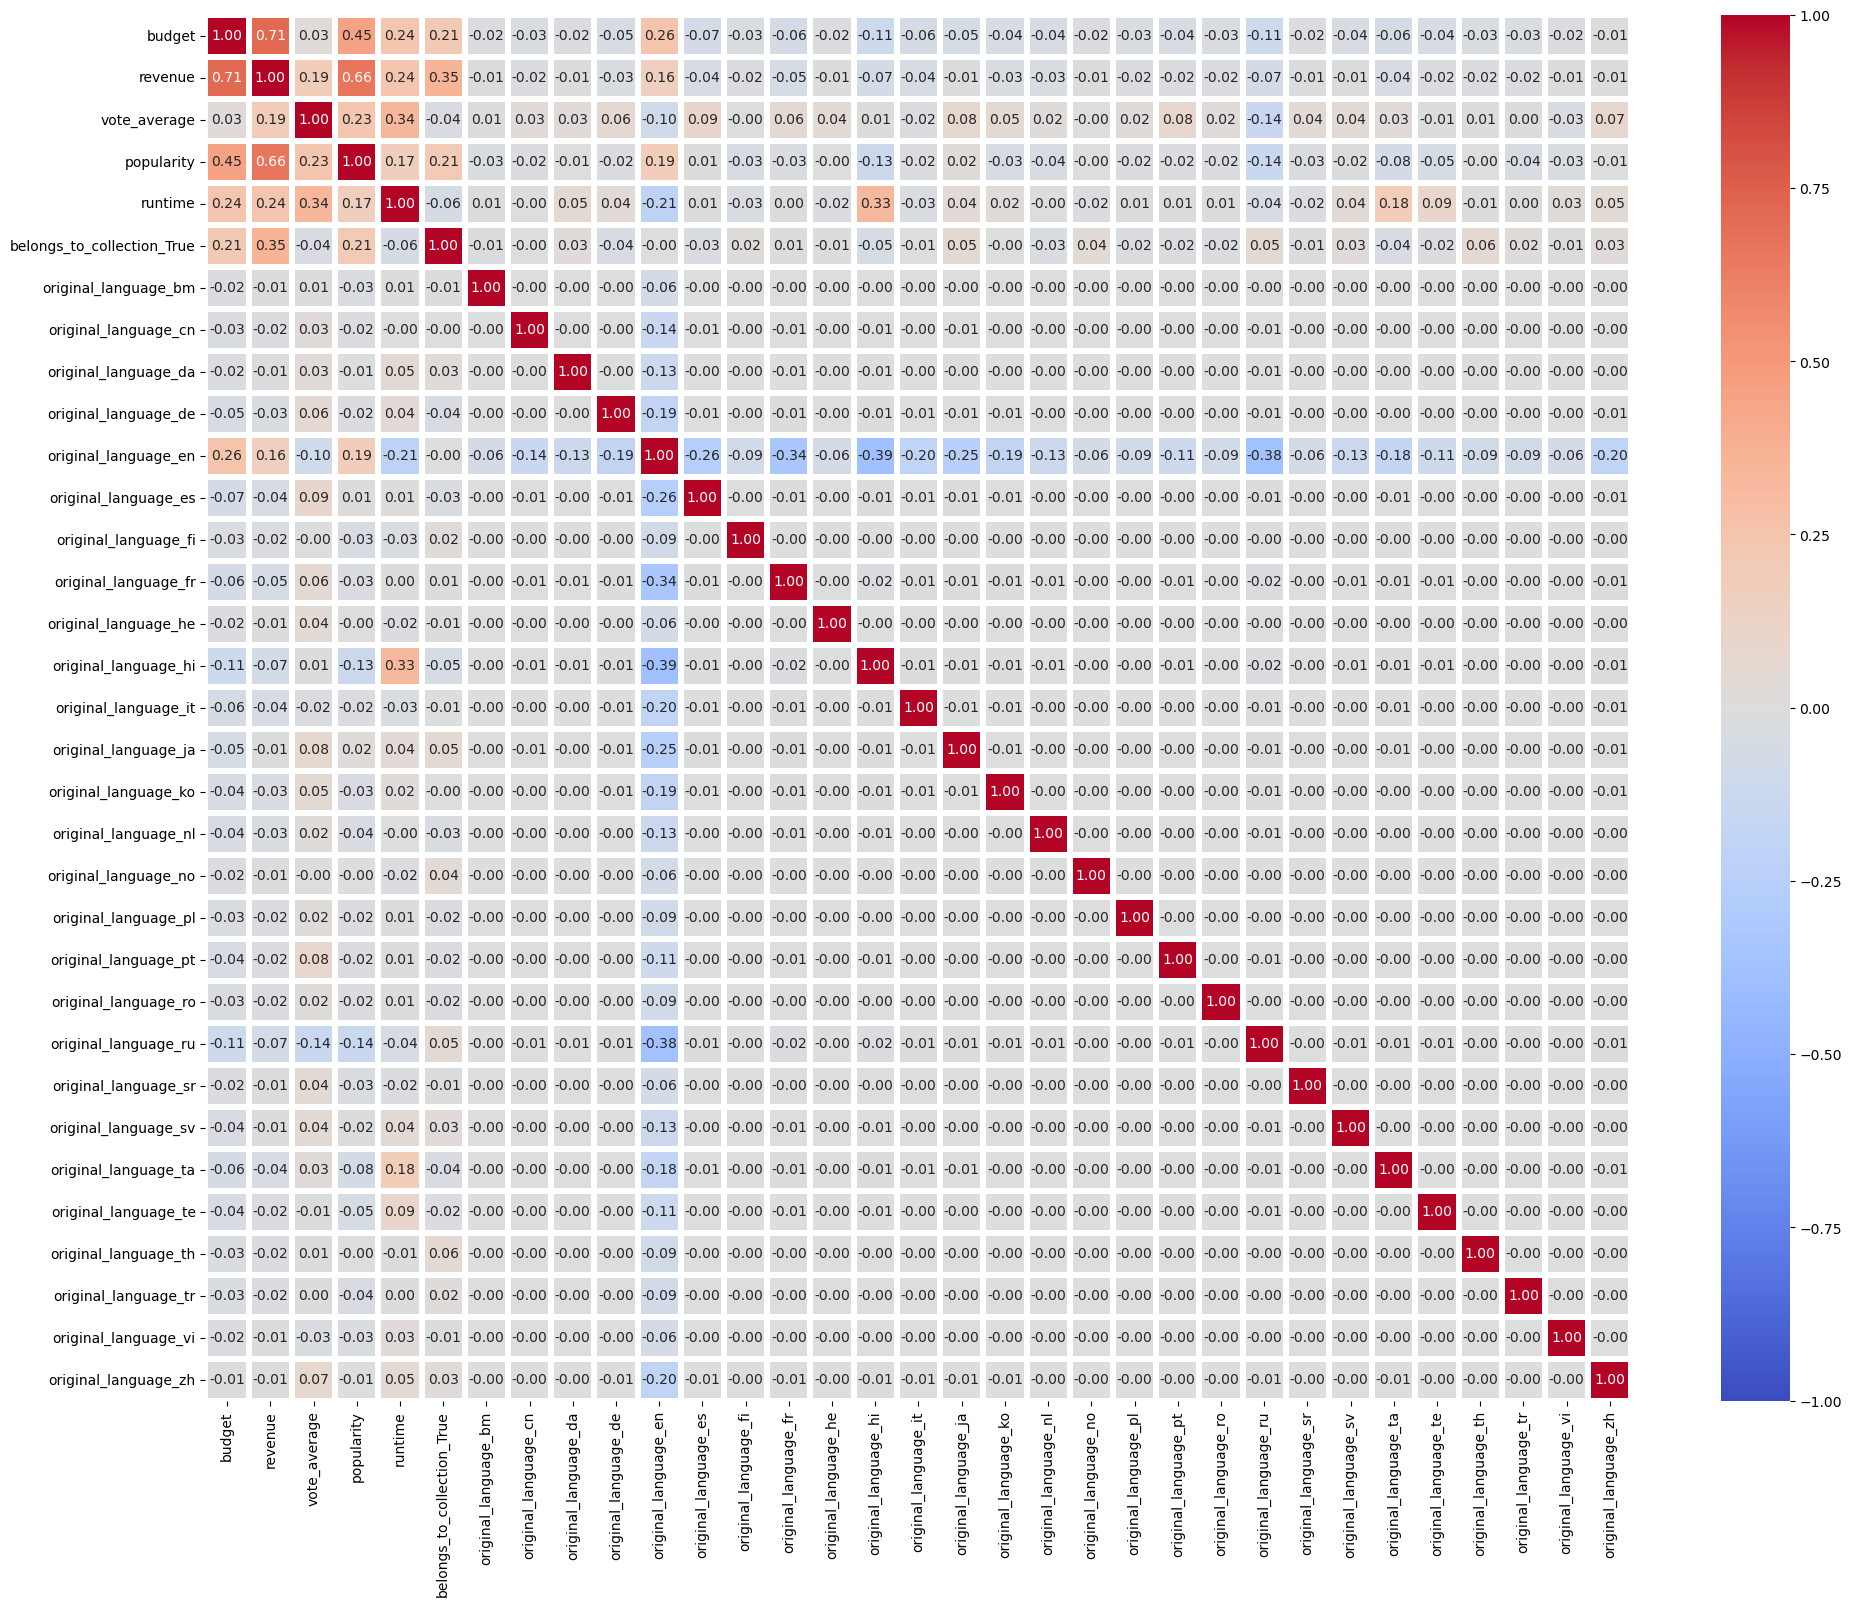

In [211]:
plt.figure(figsize = (23, 18))
sns.heatmap(data = df_dumm_new.corr(numeric_only = True), 
            annot = True, 
            cmap = "coolwarm", 
            linewidths = 3 , 
            vmin = -1 , 
            vmax = +1,
            fmt = ".2f")
plt.show()

We can conclude that the revenue has not a significant correlation with other languages except english. So we can remove all other languages.

In [212]:
model_new = ols("revenue ~ budget + popularity  + vote_average + belongs_to_collection_True + original_language_en", data = df_dumm)
results_new = model_new.fit()
print(results_new.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                     780.7
Date:                Tue, 23 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:40:50   Log-Likelihood:                -10548.
No. Observations:                1780   AIC:                         2.111e+04
Df Residuals:                    1774   BIC:                         2.114e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

# Well Done!